# CIDAS Real-Time Analysis
## Analyzes Actual Diagnoses from Streamlit App

**Important:** This notebook reads from `diagnosis_history.json` which contains ACTUAL diagnoses made in the Streamlit app.

**Workflow:**
1. Make diagnoses in Streamlit app
2. Run this notebook
3. See figures for YOUR actual cases (not test data)

In [14]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json
import os
from datetime import datetime

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
# Define output directory
OUTPUT_DIR = 'CIDAS_RealTime_Analysis'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [15]:
# Load ACTUAL diagnosis history from Streamlit app
filename = 'diagnosis_history.json'

if not os.path.exists(filename):
    print("ERROR: No diagnosis history found!")
    print("")
    print("Please:")
    print("1. Open Streamlit app: streamlit run app.py")
    print("2. Complete at least one diagnosis")
    print("3. Come back and run this notebook")
    raise FileNotFoundError(f"File '{filename}' not found. Please make diagnoses in the app first.")

# Load actual diagnoses
with open(filename, 'r') as f:
    diagnoses = json.load(f)

# Convert to DataFrame
df = pd.DataFrame(diagnoses)

print(f"Loaded {len(df)} ACTUAL diagnoses from Streamlit app")
print(f"")
print("Diagnosis summary:")
print(df['diagnosis'].value_counts())
print(f"")
print("Risk level summary:")
print(df['risk_level'].value_counts())

Loaded 7 ACTUAL diagnoses from Streamlit app

Diagnosis summary:
diagnosis
COVID-19    7
Name: count, dtype: int64

Risk level summary:
risk_level
low       5
medium    2
Name: count, dtype: int64


In [16]:
# will only display the first few cases
print("First few diagnoses:")
df[['case_id', 'timestamp', 'diagnosis', 'confidence', 'risk_level']].head()

First few diagnoses:


,case_id,timestamp,diagnosis,confidence,risk_level
0,LIVE_1,2026-01-27 17:01:50,COVID-19,0.95,low
1,LIVE_2,2026-01-27 17:02:15,COVID-19,0.90,low
2,LIVE_3,2026-01-27 17:02:24,COVID-19,0.95,low
3,LIVE_4,2026-01-27 17:02:34,COVID-19,0.88,low
4,LIVE_5,2026-01-27 22:27:03,COVID-19,0.95,low


Saved: CIDAS_RealTime_Analysis/CIDAS_RealTime_Dashboard.png


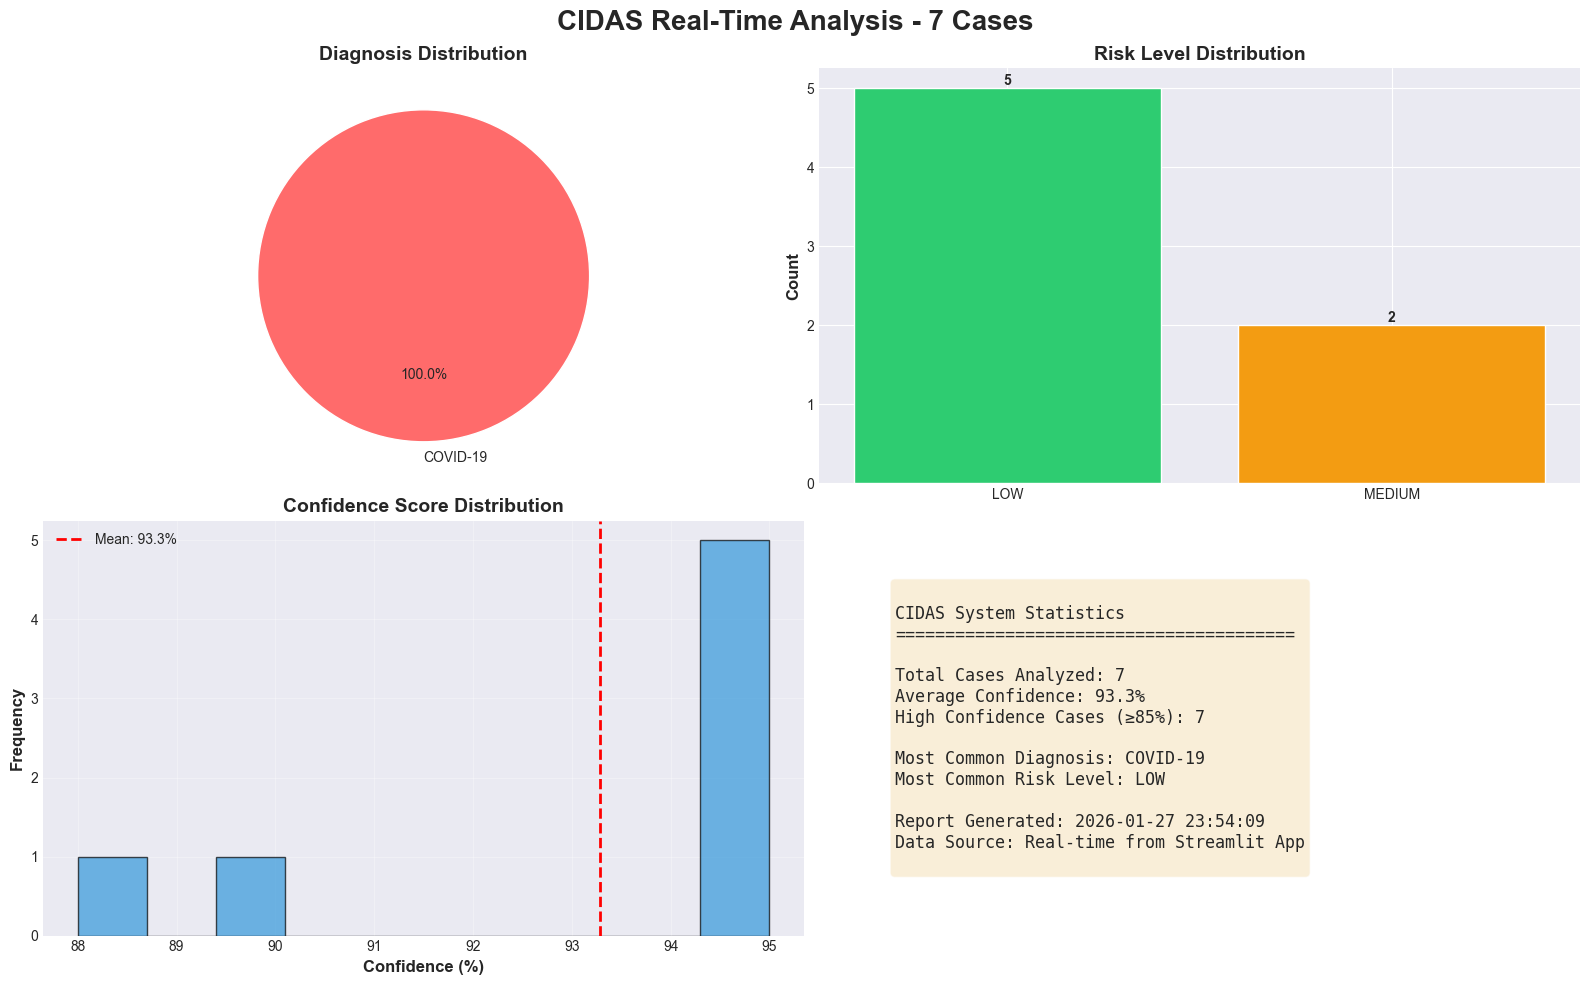

In [17]:
# Figure 1: Comprehensive Dashboard
fig = plt.figure(figsize=(16, 10))
fig.suptitle(f'CIDAS Real-Time Analysis - {len(df)} Cases', fontsize=20, fontweight='bold')

# Diagnosis Distribution (Pie Chart)
ax1 = plt.subplot(2, 2, 1)
diagnosis_counts = df['diagnosis'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
ax1.pie(diagnosis_counts.values, labels=diagnosis_counts.index, autopct='%1.1f%%',
        startangle=90, colors=colors[:len(diagnosis_counts)])
ax1.set_title('Diagnosis Distribution', fontsize=14, fontweight='bold')

# Risk Distribution (Bar Chart)
ax2 = plt.subplot(2, 2, 2)
risk_counts = df['risk_level'].value_counts()
risk_order = ['low', 'medium', 'high', 'critical']
risk_counts = risk_counts.reindex([r for r in risk_order if r in risk_counts.index], fill_value=0)
risk_colors = {'low': '#2ECC71', 'medium': '#F39C12', 'high': '#E67E22', 'critical': '#E74C3C'}
bars = ax2.bar(range(len(risk_counts)), risk_counts.values, 
               color=[risk_colors[r] for r in risk_counts.index])
ax2.set_xticks(range(len(risk_counts)))
ax2.set_xticklabels([r.upper() for r in risk_counts.index])
ax2.set_ylabel('Count', fontsize=12, fontweight='bold')
ax2.set_title('Risk Level Distribution', fontsize=14, fontweight='bold')
for bar, count in zip(bars, risk_counts.values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(count)}', ha='center', va='bottom', fontweight='bold')

# Confidence Score Distribution
ax3 = plt.subplot(2, 2, 3)
ax3.hist(df['confidence'] * 100, bins=10, color='#3498db', alpha=0.7, edgecolor='black')
ax3.axvline(df['confidence'].mean() * 100, color='red', linestyle='--', linewidth=2,
            label=f'Mean: {df["confidence"].mean()*100:.1f}%')
ax3.set_xlabel('Confidence (%)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax3.set_title('Confidence Score Distribution', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Statistics Box
ax4 = plt.subplot(2, 2, 4)
ax4.axis('off')
stats_text = f"""
CIDAS System Statistics
{'='*40}

Total Cases Analyzed: {len(df)}
Average Confidence: {df['confidence'].mean()*100:.1f}%
High Confidence Cases (≥85%): {len(df[df['confidence'] >= 0.85])}

Most Common Diagnosis: {df['diagnosis'].mode()[0]}
Most Common Risk Level: {df['risk_level'].mode()[0].upper()}

Report Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Data Source: Real-time from Streamlit App
"""
ax4.text(0.1, 0.5, stats_text, fontsize=12, verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
         family='monospace')

plt.tight_layout()
# Save to CIDAS_RealTime_Analysis directory
plt.savefig(f'{OUTPUT_DIR}/CIDAS_RealTime_Dashboard.png', dpi=300, bbox_inches='tight')
print(f"Saved: {OUTPUT_DIR}/CIDAS_RealTime_Dashboard.png")
plt.show()

Saved: CIDAS_RealTime_Analysis/CIDAS_RealTime_Diagnosis_Distribution.png


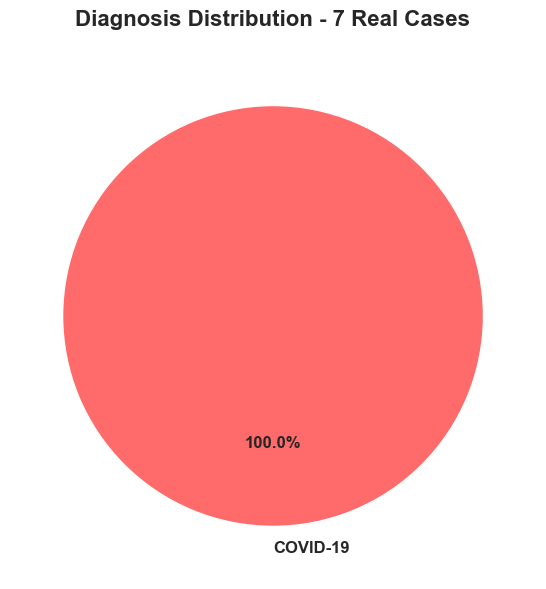

In [18]:
# Figure 2: Diagnosis Distribution (Detailed)
fig, ax = plt.subplots(figsize=(10, 6))

diagnosis_counts = df['diagnosis'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

wedges, texts, autotexts = ax.pie(diagnosis_counts.values, 
                                    labels=diagnosis_counts.index,
                                    autopct='%1.1f%%',
                                    startangle=90,
                                    colors=colors[:len(diagnosis_counts)],
                                    textprops={'fontsize': 12, 'fontweight': 'bold'})

ax.set_title(f'Diagnosis Distribution - {len(df)} Real Cases', 
             fontsize=16, fontweight='bold', pad=20)


plt.tight_layout()
# Save to CIDAS_RealTime_Analysis directory
plt.savefig(f'{OUTPUT_DIR}/CIDAS_RealTime_Diagnosis_Distribution.png', dpi=300, bbox_inches='tight')
print(f"Saved: {OUTPUT_DIR}/CIDAS_RealTime_Diagnosis_Distribution.png")
plt.show()

Saved: CIDAS_RealTime_Analysis/CIDAS_RealTime_Risk_Distribution.png


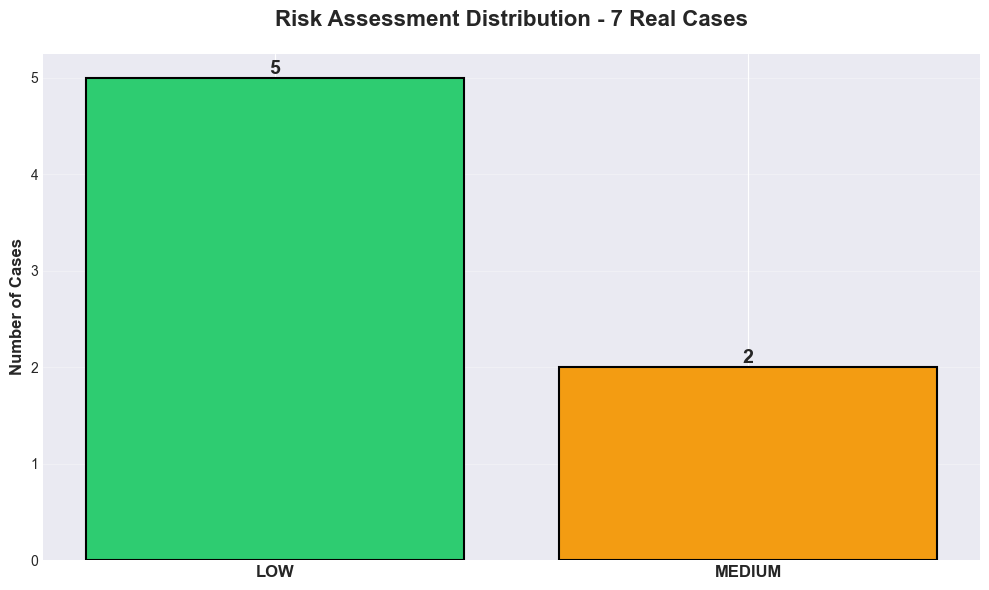

In [19]:
# Figure 3: Risk Assessment Distribution (Detailed)
fig, ax = plt.subplots(figsize=(10, 6))

risk_counts = df['risk_level'].value_counts()
risk_order = ['low', 'medium', 'high', 'critical']
risk_counts = risk_counts.reindex([r for r in risk_order if r in risk_counts.index], fill_value=0)

risk_colors = {
    'low': '#2ECC71',
    'medium': '#F39C12', 
    'high': '#E67E22',
    'critical': '#E74C3C'
}

bars = ax.bar(range(len(risk_counts)), risk_counts.values,
              color=[risk_colors[r] for r in risk_counts.index],
              edgecolor='black', linewidth=1.5)

ax.set_xticks(range(len(risk_counts)))
ax.set_xticklabels([r.upper() for r in risk_counts.index], fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Cases', fontsize=12, fontweight='bold')
ax.set_title(f'Risk Assessment Distribution - {len(df)} Real Cases', 
             fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, axis='y')

# Add count labels on bars
for bar, count in zip(bars, risk_counts.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(count)}', ha='center', va='bottom', 
            fontsize=14, fontweight='bold')

plt.tight_layout()
# Save to CIDAS_RealTime_Analysis directory
plt.savefig(f'{OUTPUT_DIR}/CIDAS_RealTime_Risk_Distribution.png', dpi=300, bbox_inches='tight')
print(f"Saved: {OUTPUT_DIR}/CIDAS_RealTime_Risk_Distribution.png")
plt.show()

Saved: CIDAS_RealTime_Analysis/CIDCIDAS_RealTime_TimelineAS_RealTime_Dashboard.png


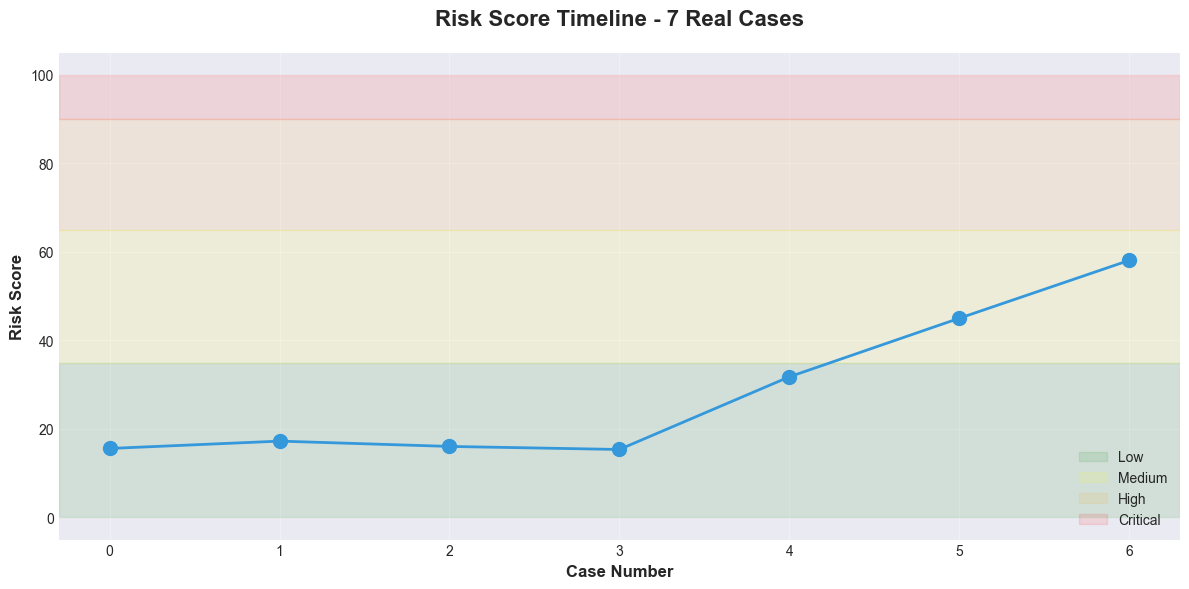

In [20]:
# Figure 4: Timeline View (if multiple cases)
if len(df) > 1:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Convert timestamps
    df['timestamp_dt'] = pd.to_datetime(df['timestamp'])
    df_sorted = df.sort_values('timestamp_dt')
    
    # Plot risk scores over time
    ax.plot(range(len(df_sorted)), df_sorted['risk_score'], 
            marker='o', linewidth=2, markersize=10, color='#3498db')
    
    ax.set_xlabel('Case Number', fontsize=12, fontweight='bold')
    ax.set_ylabel('Risk Score', fontsize=12, fontweight='bold')
    ax.set_title(f'Risk Score Timeline - {len(df)} Real Cases', 
                 fontsize=16, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3)
    
    # Add risk level zones
    ax.axhspan(0, 35, alpha=0.1, color='green', label='Low')
    ax.axhspan(35, 65, alpha=0.1, color='yellow', label='Medium')
    ax.axhspan(65, 90, alpha=0.1, color='orange', label='High')
    ax.axhspan(90, 100, alpha=0.1, color='red', label='Critical')
    
    ax.legend()
    

    plt.tight_layout()
    # Save to CIDAS_RealTime_Analysis directory
    plt.savefig(f'{OUTPUT_DIR}/CIDAS_RealTime_Timeline.png', dpi=300, bbox_inches='tight')
    print(f"Saved: {OUTPUT_DIR}/CIDCIDAS_RealTime_TimelineAS_RealTime_Dashboard.png")
    plt.show()
else:
    print("Need at least 2 cases for timeline view")

In [21]:
# Export Summary Statistics
summary = {
    'Total Cases': len(df),
    'Average Confidence': f"{df['confidence'].mean()*100:.1f}%",
    'High Confidence Cases': len(df[df['confidence'] >= 0.85]),
    'COVID-19 Cases': len(df[df['diagnosis'] == 'COVID-19']),
    'Influenza Cases': len(df[df['diagnosis'] == 'Influenza']),
    'Common Cold Cases': len(df[df['diagnosis'] == 'Common Cold']),
    'Allergies Cases': len(df[df['diagnosis'] == 'Allergies']),
    'Low Risk': len(df[df['risk_level'] == 'low']),
    'Medium Risk': len(df[df['risk_level'] == 'medium']),
    'High Risk': len(df[df['risk_level'] == 'high']),
    'Critical Risk': len(df[df['risk_level'] == 'critical']),
}

summary_df = pd.DataFrame(list(summary.items()), columns=['Metric', 'Value'])
summary_df.to_csv('CIDAS_RealTime_Summary.csv', index=False)
# Save to CIDAS_RealTime_Analysis directory

print(f"Saved: {OUTPUT_DIR}/CIDAS_RealTime_Summary.csv")
print("")
print("Summary Statistics:")
print(summary_df.to_string(index=False))

# Save to CIDAS_RealTime_Analysis directory
summary_df.to_csv(f'{OUTPUT_DIR}/CIDAS_RealTime_Summary.csv', index=False)


Saved: CIDAS_RealTime_Analysis/CIDAS_RealTime_Summary.csv

Summary Statistics:
               Metric Value
          Total Cases     7
   Average Confidence 93.3%
High Confidence Cases     7
       COVID-19 Cases     7
      Influenza Cases     0
    Common Cold Cases     0
      Allergies Cases     0
             Low Risk     5
          Medium Risk     2
            High Risk     0
        Critical Risk     0


In [22]:
# Final Summary
print("="*60)
print("REAL-TIME ANALYSIS COMPLETE")
print("="*60)
print("")
print(f"Analyzed: {len(df)} ACTUAL cases from Streamlit app")
print(f"Generated Files in CIDAS_RealTime_Analysis folder:")
print("   1. CIDAS_RealTime_Dashboard.png")
print("   2. CIDAS_RealTime_Diagnosis_Distribution.png")
print("   3. CIDAS_RealTime_Risk_Distribution.png")
if len(df) > 1:
    print("   4. CIDAS_RealTime_Timeline.png")
print("   5. CIDAS_RealTime_Summary.csv")
print("")
print("="*60)

REAL-TIME ANALYSIS COMPLETE

Analyzed: 7 ACTUAL cases from Streamlit app
Generated Files in CIDAS_RealTime_Analysis folder:
   1. CIDAS_RealTime_Dashboard.png
   2. CIDAS_RealTime_Diagnosis_Distribution.png
   3. CIDAS_RealTime_Risk_Distribution.png
   4. CIDAS_RealTime_Timeline.png
   5. CIDAS_RealTime_Summary.csv

